In [98]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [71]:
data_email = pd.read_csv('emails.csv')

In [72]:
data_email

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [73]:
data_email = data_email.rename(columns = {'text':'Message', 'spam':'Category'})

In [74]:
data_email['Category'].value_counts()

Category
0    4360
1    1368
Name: count, dtype: int64

In [76]:
X = data_email['Message']
y = data_email['Category']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [78]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [79]:
rnd_clf = RandomForestClassifier(n_estimators = 500, max_leaf_nodes = 2000, class_weight='balanced', n_jobs = -1)

In [80]:
rnd_clf.fit(X_train_vec, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,2000
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
y_pred = rnd_clf.predict(X_test_vec)
accuracy_score(y_test, y_pred)

0.9834205933682374

In [95]:
matrix = confusion_matrix(y_test, y_pred)
matrix_display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = ['spam', 'ham'])

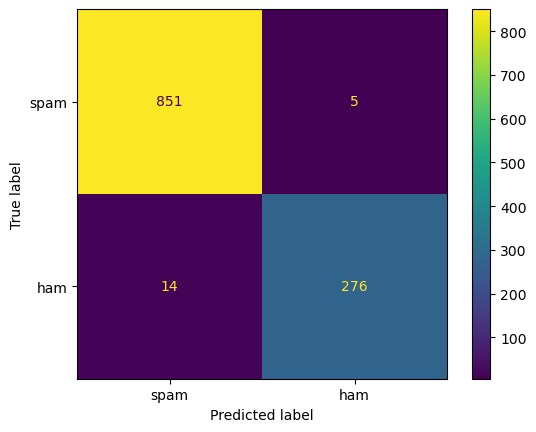

In [96]:
matrix_display.plot()

In [101]:
train_pred = rnd_clf.predict(X_train_vec)
test_pred = rnd_clf.predict(X_test_vec)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print('Train Accuracy: ', train_accuracy)
print('Test Accuracy: ', test_accuracy)

Train Accuracy:  1.0
Test Accuracy:  0.9834205933682374


Text(0.5, 1.0, 'Training and Testing Accuracy')

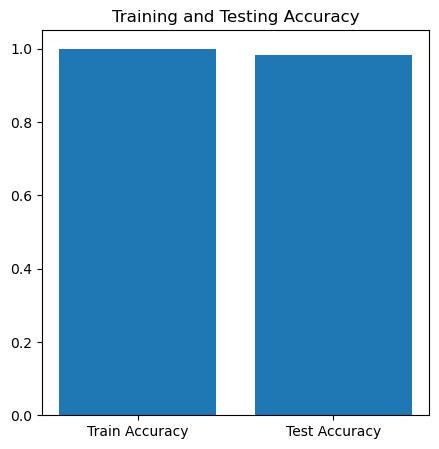

In [107]:
plt.figure(figsize = (5,5))

plt.bar(['Train Accuracy','Test Accuracy'], [train_accuracy, test_accuracy])

plt.title('Training and Testing Accuracy')

In [82]:
def pred_message(message):
    v = vectorizer.transform([message])
    predict = rnd_clf.predict(v)[0]
    return 'spam' if predict == 1 else 'ham'

In [111]:
user_input = input('Enter a message:\n')
result = pred_message(user_input)
print('Your message is', result)

Enter a message:
 Good morning here is a picture of my cat, hope you're having a nice day 


Your message is ham
